In [1]:
import h5py
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
import torch

from robustness.audio_functions.jsinV3DataLoader_precombined import *
import lightning_scripts.jsinV3DataLoader_precombined_batched as batched_loading
from robustness.audio_functions.audio_transforms import *

In [2]:
source_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/jsinV3BalancedProcessed/sr_20000/splits/valid_stackedDataframeHDF_n150_VJRUH4IEPDGPNH2JZMULSQKOWYNQ6KMM.pdh5'
noise_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music.pdh5' 
dataframe_metadata = pd.read_hdf(source_h5)
source_files = h5py.File(source_h5, 'r')

noise_metadata = pd.read_hdf(noise_h5)
noise_files = h5py.File(noise_h5, 'r')

In [3]:
signal_0 = source_files['ndarray_data']['signal'][0:2]
noise_0 = noise_files['ndarray_data']['signal'][1]

In [4]:
signal_0[1].shape

(49200,)

(2,)


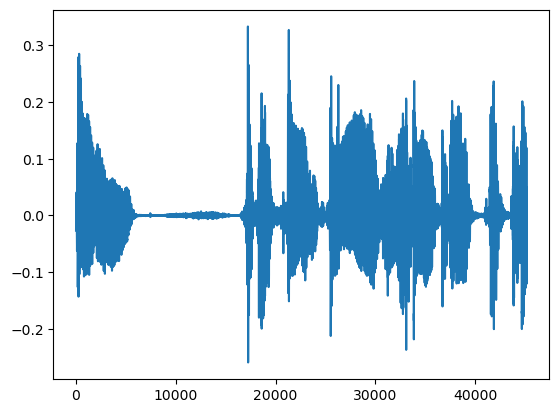

In [5]:
print(signal_0.shape)
plt.plot(signal_0[0])
Audio(signal_0[0], rate=20000)

(200157,)


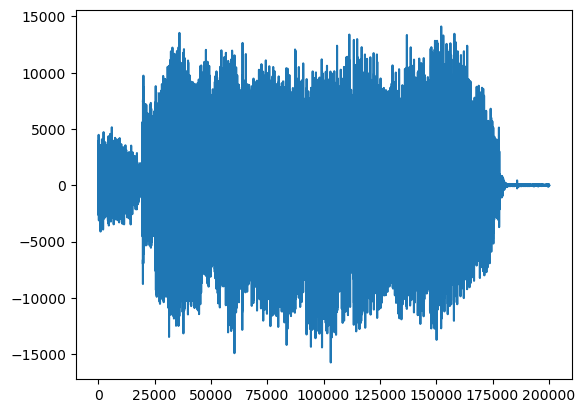

In [6]:
print(noise_0.shape)
plt.plot(noise_0)
Audio(noise_0, rate=20000)

### Dev torchaudio augmentations 

torchaudio has a wrapper for the sox audio library, letting us apply the high-quality sox augmentations to torch tensors in memory.

In [7]:
import torchaudio 
import torchaudio.transforms as T 
import scipy
from torchaudio.sox_effects import apply_effects_tensor

In [8]:
torchaudio.sox_effects.effect_names()

['allpass',
 'band',
 'bandpass',
 'bandreject',
 'bass',
 'bend',
 'biquad',
 'chorus',
 'channels',
 'compand',
 'contrast',
 'dcshift',
 'deemph',
 'delay',
 'dither',
 'divide',
 'downsample',
 'earwax',
 'echo',
 'echos',
 'equalizer',
 'fade',
 'fir',
 'firfit',
 'flanger',
 'gain',
 'highpass',
 'hilbert',
 'loudness',
 'lowpass',
 'mcompand',
 'norm',
 'oops',
 'overdrive',
 'pad',
 'phaser',
 'pitch',
 'rate',
 'remix',
 'repeat',
 'reverb',
 'reverse',
 'riaa',
 'silence',
 'sinc',
 'speed',
 'stat',
 'stats',
 'stretch',
 'swap',
 'synth',
 'tempo',
 'treble',
 'tremolo',
 'trim',
 'upsample',
 'vad',
 'vol']

In [9]:
### Set params for manipulations - same used in Saddler & McDermott 2024
np.random.seed(0)

def apply_butterworth_filter(y,
                             sr,
                             order,
                             cutoff,
                             btype='bandpass',
                             mode='lfilter'):
    """
    """
    dtype = y.dtype
    b, a = scipy.signal.butter(
        order,
        cutoff,
        btype=btype,
        analog=False,
        output='ba',
        fs=sr)
    if mode.lower() == 'filtfilt':
        y_out = scipy.signal.filtfilt(b, a, y)
    elif mode.lower() == 'lfilter':
        y_out = scipy.signal.lfilter(b, a, y)
    else:
        raise ValueError("filter mode `{}` not recognized".format(mode))
    return y_out.astype(dtype)

    
def loguniform(low, high, size=None):
    """
    Helper function to draw samples uniformly on a log scale.
    """
    return np.exp(np.random.uniform(low=np.log(low), high=np.log(high), size=size))


def sample_augments(speech=True,
                    sample_rate=20_000,
                    effect_types = ['filter', 'pitch',  'tempo'],
                    ):
    """
    """
    # Sample bandpass filter parameters
    n_effects = np.random.randint(low=0, high=len(effect_types)+1)
    effect_choice = np.random.choice(effect_types, size=n_effects, replace=False)
    # sample if using filtering
    dict_kwargs_butterworth = {} 
    if 'filter' in effect_choice:
        nyquist = (sample_rate // 2) - 1 # limit must be exactly under and not equal to for filtering 
        if speech:
            ## Use frequency ranges that overlap speech signals 
            range_bandpass_freq_low = [4e1, 4e2]
            range_bandpass_freq_high = [4e3, 10e3]
            bandpass_freq_low = loguniform(*range_bandpass_freq_low)
            bandpass_freq_high = loguniform(*range_bandpass_freq_high)
        else:
            ## Can use wider frequency range for non-speech signals
            range_bandpass_center_frequency = [16e1, 10e3]
            range_bandpass_bandwidth_octave = [2, 4]
            bandpass_center_frequency = loguniform(*range_bandpass_center_frequency)
            bandpass_bandwidth_octave = loguniform(*range_bandpass_bandwidth_octave)
            bandpass_freq_low = np.power(2, -bandpass_bandwidth_octave/2) * bandpass_center_frequency
            bandpass_freq_high = np.power(2, bandpass_bandwidth_octave/2) * bandpass_center_frequency
        # sample order for nth order butterworth filter 
        list_bandpass_order = [1, 2, 3, 4]
        bandpass_order_int = np.random.choice(list_bandpass_order)
        # clip hz based on nyquist 
        if bandpass_freq_low < 20:
            bandpass_freq_low = 20 
        if bandpass_freq_high > nyquist:
            bandpass_freq_high = nyquist 

        # stack as kwargs dict 
        dict_kwargs_butterworth = {'order': bandpass_order_int,
                            'cutoff': [bandpass_freq_low, bandpass_freq_high],
                            'btype': 'bandpass'
                            }

    # Sample sox augmentations
    effects_to_apply = []
    if n_effects > 0:
        for effect in effect_choice:
            if effect == 'pitch':
                pitch_n_semitones = np.random.uniform(-0.5, 0.5)
                # pitch args are n semitones
                effects_to_apply.append(['pitch', f"{pitch_n_semitones}"])
                # chain resample for identical output from sox 
                effects_to_apply.append(['rate', f"{sample_rate}"])
            elif effect == 'tempo':
                tempo_factor = np.random.uniform(0.90, 1.10)
                # tempo args are factor
                effects_to_apply.append(['tempo', f"{tempo_factor}"])

    return dict_kwargs_butterworth, effects_to_apply




In [10]:
sample_rate = 20000
eg_sig = signal_0[0]
# print(torch_signals.shape)
display(Audio(eg_sig, rate=20_000))

filter_kwargs, sox_effects = sample_augments()
print(f"{filter_kwargs=}")
## Apply filter 
if len(filter_kwargs) > 0:
    eg_sig = apply_butterworth_filter(eg_sig, sample_rate, **filter_kwargs)
    display(Audio(eg_sig, rate=20_000))

eg_sig = torch.from_numpy(eg_sig).float()
print(f"{sox_effects=}")
waveform, output_rate = apply_effects_tensor(
            eg_sig.unsqueeze(0), sample_rate, sox_effects, channels_first=True)

print(waveform.shape)
print(output_rate)
display(Audio(waveform, rate=output_rate))

filter_kwargs={}
sox_effects=[]
torch.Size([1, 45200])
20000


### Dev class for matched augment 

In [137]:
x = np.ones(2)
torch.is_tensor(x)

False

In [11]:
class MatchedRandomSignalAugment(torch.nn.Module):
    """
    Randomly applies the same set of signal augmentations to two signals. 
    Samples whether to apply filtering, pitch shifting, or tempo change 
    augmentations to signals, and the parameters for each augmentation. 
    """
    def __init__(self, sampling_rate=20000):
        super().__init__()
        self.sampling_rate = sampling_rate
    
    def apply_butterworth_filter(self,
                                x,
                                order,
                                cutoff,
                                btype='bandpass',
                                ):
        """
        """
        if isinstance(x, torch.Tensor):
            x = x.numpy()
        dtype = x.dtype
        b, a = scipy.signal.butter(
            order,
            cutoff,
            btype=btype,
            analog=False,
            output='ba',
            fs=self.sampling_rate)
        x = scipy.signal.lfilter(b, a, x)

        return x.astype(dtype)
    
    def apply_sox_augments(self, x, sox_effects):
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x).float()
        if x.ndim == 1:
            x = x.unsqueeze(0)
        x, output_rate = apply_effects_tensor(x, self.sampling_rate, sox_effects, channels_first=True)
        assert output_rate == self.sampling_rate, "Sox effects changed sample rate to {output_rate} from {self.sampling_rate}"
        return x 

    def __call__(self, signal_1, signal_2, speech=True, print_augments=False):
        ### Get shared augmentations:
        filter_kwargs, sox_effects = sample_augments(speech=speech)
        if print_augments:
            print(filter_kwargs)
            print(sox_effects)
        # apply to signal 1 
        if len(filter_kwargs) > 0:
            signal_1 = self.apply_butterworth_filter(signal_1, **filter_kwargs)
        signal_1 = self.apply_sox_augments(signal_1, sox_effects)

        # apply to signal 2 
        if len(filter_kwargs) > 0:
            signal_2 = self.apply_butterworth_filter(signal_2, **filter_kwargs)
        signal_2 = self.apply_sox_augments(signal_2, sox_effects)
        return signal_1, signal_2

matched_augment = MatchedRandomSignalAugment(sampling_rate=20_000)

In [12]:
## try augmenting both signals 

signal_1, signal_2 = matched_augment(*signal_0, print_augments=True)
display(Audio(signal_1, rate=20_000))
display(Audio(signal_2, rate=20_000))

{'order': np.int64(3), 'cutoff': [np.float64(176.99219056766543), np.float64(5973.012862489375)], 'btype': 'bandpass'}
[['tempo', '0.9113425954634886'], ['pitch', '-0.2273437054198868'], ['rate', '20000']]


In [13]:
### Try import 
sys.path.append('../')
from robustness.audio_functions.audio_transforms import MatchedRandomSignalAugment

In [14]:
matched_signal_augment = MatchedRandomSignalAugment(20_000)

In [15]:
signal_1, signal_2 = matched_signal_augment(*signal_0)


### Pytorch sox interface hangs in multiprocessing environments try alternatives

In [66]:
import sox


tfm = sox.Transformer()
tfm.pitch(1)
tfm.tempo(1.2, 's', False)

raw_eg = signal_0[0]

auged = tfm.build_array(input_array=raw_eg, sample_rate_in=20_000)

In [68]:
print(auged.shape)
Audio(auged, rate=20_000)

(37667,)


### Dev module for sox transforms

In [80]:
def pad_or_trim_to_len(x, n, mode='both', kwargs_pad={}):
    """
    Increases or decreases the length of a one-dimensional signal
    by either padding or triming the array. If the difference
    between `len(x)` and `n` is odd, this function will default to
    adding/removing the extra sample at the end of the signal.
    
    Args
    ----
    x (np.ndarray): one-dimensional input signal
    n (int): length of output signal
    mode (str): specify which end of signal to modify
        (default behavior is to symmetrically modify both ends)
    kwargs_pad (dict): keyword arguments for np.pad function
    
    Returns
    -------
    x_out (np.ndarray): one-dimensional signal with length `n`
    """
    assert len(np.array(x).shape) == 1, "input must be 1D array"
    assert mode.lower() in ['both', 'start', 'end']
    n_diff = np.abs(len(x) - n)
    if len(x) > n:
        if mode.lower() == 'end':
            x_out = x[:n]
        elif mode.lower() == 'start':
            x_out = x[-n:]
        else:
            x_out = x[int(np.floor(n_diff / 2)):-int(np.ceil(n_diff / 2))]
    elif len(x) < n:
        if mode.lower() == 'end':
            pad_width = [0, n_diff]
        elif mode.lower() == 'start':
            pad_width = [n_diff, 0]
        else:
            pad_width = [int(np.floor(n_diff / 2)), int(np.ceil(n_diff / 2))]
        kwargs = {'mode': 'constant'}
        kwargs.update(kwargs_pad)
        x_out = np.pad(x, pad_width, **kwargs)
    else:
        x_out = x
    assert len(x_out) == n
    return x_out


def apply_sox_transformations(y, sr, kwargs_pitch={}, kwargs_tempo={}):
    """
    """
    dtype = y.dtype
    tfm = sox.Transformer()
    if kwargs_pitch:
        tfm.pitch(**kwargs_pitch)
    if kwargs_tempo:
        tfm.tempo(**kwargs_tempo)
    y_out = tfm.build_array(input_filepath=None, input_array=y, sample_rate_in=sr)
    y_out = pad_or_trim_to_len(y_out, len(y))
    return y_out.astype(dtype)


def augment_excerpt(y, aug_dict, sr=44100):
    """
    """
    kwargs_sox = aug_dict.get('kwargs_sox', {})
    if kwargs_sox:
        y_out = apply_sox_transformations(y, sr, **kwargs_sox)
        if np.isfinite(np.sqrt(np.mean(np.square(y_out)))):
            y = y_out
        else:
            print("[augment_excerpt] `apply_sox_transformations` produced Inf/NaN (skipped)")
    kwargs_butterworth = aug_dict.get('kwargs_butterworth', {})
    if kwargs_butterworth:
        y_out = apply_butterworth_filter(y, sr, **kwargs_butterworth)
        if np.isfinite(np.sqrt(np.mean(np.square(y_out)))):
            y = y_out
        else:
            print("[augment_excerpt] `apply_butterworth_filter` produced Inf/NaN (skipped)")
    return y


def sample_augments(speech=True,
                    sample_rate=20_000,
                    effect_types = ['filter', 'pitch',  'tempo'],
                    ):
    """
    """
    # Sample bandpass filter parameters
    n_effects = np.random.randint(low=0, high=len(effect_types)+1)
    effect_choice = np.random.choice(effect_types, size=n_effects, replace=False)
    # sample if using filtering
    aug_dict = {}
    if 'filter' in effect_choice:
        nyquist = (sample_rate // 2) - 1 # limit must be exactly under and not equal to for filtering 
        if speech:
            ## Use frequency ranges that overlap speech signals 
            range_bandpass_freq_low = [4e1, 4e2]
            range_bandpass_freq_high = [4e3, 10e3]
            bandpass_freq_low = loguniform(*range_bandpass_freq_low)
            bandpass_freq_high = loguniform(*range_bandpass_freq_high)
        else:
            ## Can use wider frequency range for non-speech signals
            range_bandpass_center_frequency = [16e1, 10e3]
            range_bandpass_bandwidth_octave = [2, 4]
            bandpass_center_frequency = loguniform(*range_bandpass_center_frequency)
            bandpass_bandwidth_octave = loguniform(*range_bandpass_bandwidth_octave)
            bandpass_freq_low = np.power(2, -bandpass_bandwidth_octave/2) * bandpass_center_frequency
            bandpass_freq_high = np.power(2, bandpass_bandwidth_octave/2) * bandpass_center_frequency
        # sample order for nth order butterworth filter 
        list_bandpass_order = [1, 2, 3, 4]
        bandpass_order_int = np.random.choice(list_bandpass_order)
        # clip hz based on nyquist 
        if bandpass_freq_low < 20:
            bandpass_freq_low = 20 
        if bandpass_freq_high > nyquist:
            bandpass_freq_high = nyquist 

        # stack as kwargs dict 
        aug_dict["kwargs_butterworth"] = {'order': bandpass_order_int,
                            'cutoff': [bandpass_freq_low, bandpass_freq_high],
                            'btype': 'bandpass'
                            }

    # Sample sox augmentations
    dict_kwargs_sox = {}
    for effect in effect_choice:
        if effect == 'pitch':
            pitch_n_semitones = np.random.uniform(-0.5, 0.5)
            # pitch args are n semitones
            dict_kwargs_sox['kwargs_pitch'] = {
                'n_semitones': pitch_n_semitones,
                'quick': False,
            }
        elif effect == 'tempo':
            tempo_factor = np.random.uniform(0.80, 1.20)
            # tempo args are factor
            dict_kwargs_sox['kwargs_tempo'] = {
                            'factor': tempo_factor,
                            'audio_type': 's',
                            'quick': False,
            }
            
    aug_dict['kwargs_sox'] = dict_kwargs_sox

    return aug_dict



In [81]:
aug_dict = sample_augments()
print(aug_dict)
sr = 20_000
raw_eg = signal_0[0]
print(raw_eg.shape)
display(Audio(raw_eg, rate = sr ))

# apply augment:
augmented = augment_excerpt(raw_eg, aug_dict, sr=sr)
print(augmented.shape)
display(Audio(augmented, rate = sr ))


{'kwargs_butterworth': {'order': np.int64(3), 'cutoff': [np.float64(129.13053548823038), np.float64(9265.326577057038)], 'btype': 'bandpass'}, 'kwargs_sox': {'kwargs_tempo': {'factor': 1.0303785982224718, 'audio_type': 's', 'quick': False}, 'kwargs_pitch': {'n_semitones': 0.42929619757621407, 'quick': False}}}
(45200,)


For this stretch factor, the stretch effect has better performance.


(45200,)


### Try module

In [83]:
class MatchedRandomSignalAugmentSox(torch.nn.Module):
    """
    Randomly applies the same set of signal augmentations to two signals. 
    Samples whether to apply filtering, pitch shifting, or tempo change 
    augmentations to signals, and the parameters for each augmentation. 
    """
    def __init__(self, sample_rate=20000):
        super().__init__()
        self.sample_rate = sample_rate
    

    def __call__(self, signal_1, signal_2, speech=True, print_augments=False):
        ### Get shared augmentations:
        aug_dict = sample_augments(speech=speech)
        if print_augments:
            print(aug_dict)
        signal_1 = augment_excerpt(signal_1, aug_dict, sr=self.sample_rate)
        signal_2 = augment_excerpt(signal_2, aug_dict, sr=self.sample_rate)

        return signal_1, signal_2


In [86]:
augments = MatchedRandomSignalAugmentSox(sample_rate=sr)

sig_1, sig_2 = signal_0

aug_sig1, aug_sig2 = augments(sig_1, sig_2)

print("Raw1")
display(Audio(sig_1, rate=sr))
print("Aug1")
display(Audio(aug_sig1, rate=sr))
print("Raw2")
display(Audio(sig_2, rate=sr))
print("Aug2")
display(Audio(aug_sig2, rate=sr))

Raw1


Aug1


Raw2


Aug2


____
## Torch functional options. Not good, skipping

In [42]:
filtering, aug_amounts = sample_augments()
raw_eg = torch.from_numpy(signal_0[0]).float()
print(aug_amounts)
with torch.no_grad():
    pitch_aug = torchaudio.transforms.PitchShift(20_000, -1)(raw_eg)


[['tempo', '1.0247020202263737'], ['pitch', '-0.16199238516110825'], ['rate', '20000']]


In [45]:
# pitch_aug = torchaudio.functional.pitch_shift(raw_eg, 20_000, -1)
speed_aug, _ = torchaudio.functional.speed(raw_eg, 20_000, 1.12 )

In [47]:
print(speed_aug.shape)
Audio(speed_aug, rate=20_000)

torch.Size([40358])


In [35]:
print(raw_eg.shape)

Audio(raw_eg, rate=20_000)

torch.Size([45200])


In [40]:
print(pitch_aug.shape)
Audio(pitch_aug, rate=20_000)

torch.Size([45200])
